## Libraries, Data initialization!

In [2]:
import sys
from torch.utils.data import Dataset, DataLoader
import torchvision as tv
import numpy as np
import torchvision 
import torch
from IPython.display import display,clear_output
#import backbone.VISUAL as viz
import backbone.Custom as cust
import backbone.Imagefolder as imf


# Define the directory of your dataset

my_image_dir = "my_image_directory"



#Which dataset are you analaysing_

ModuleNotFoundError: No module named 'kornia'

## Loading Model

### Loading pretrained feature extractor

In [3]:
#model.load_state_dict(torch.load("models/model_gz_99cut.pt",map_location = torch.device("cpu")))


device = torch.device('cuda') if torch.cuda.is_available() else torch.device("cpu")

#Zoobot


model = tv.models.resnet18(weights ="IMAGENET1K_V1")

#load weights
model.fc = torch.Linear(in_features=512, out_features=4, bias=True)

#load pertrained weights

my_weights = torch.load("models/model_gz_99cut.pt",map_location = torch.device("cpu"))

model.load_state_dict(my_weights)


model.fc = torch.nn.Identity()


model.train(mode = False)


model.to(device)





importlib.reload(cust)
Dir = galaxyzoo_dir
Dir = "/idia/projects/hippo/Koketso/galaxyzoo/galaxy_zoo_12/"

dataset = torchvision.datasets.ImageFolder(Dir)
datasets = cust.train_val_dataset(dataset, val_split = 0.005)
names = [name[0].split('/')[-1][0:-4] for name in dataset.imgs]
names = cust.train_val_dataset(names, val_split = 0.005)
val_names = names['train']

Using cache found in /users/koketso/.cache/torch/hub/facebookresearch_dinov2_main
/users/koketso/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/users/koketso/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/users/koketso/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [12]:
classes = imf.classes(Dir)
summ = sum(viz.groups(classes))
print(summ)

batch_size = 32

resize = 300

#initialize image dataset with appropriate transformations
#datasets = cust.train_val_dataset(dataset, val_split = 20)

importlib.reload(cust)
transformed_dataset = cust.Custom(datasets['train'],
                                           names = val_names,
                                           resize = resize,
                                           crop = 244,
                                           mean=[0.485, 0.456, 0.406],
                                           std=[0.229, 0.224, 0.225]
                                           )   

#transformed_dataset = mb.MBFRConfident(root='./batches', train=True, download=True, transform=transform) 

loader = DataLoader(transformed_dataset, 
                    batch_size, 
                    shuffle = True,
                    num_workers = 16)
time1 = time.time()
rep = []
labells = []
names = []
images = []
name = "_"
label = 0
i = 0

with torch.no_grad():
    for image,name in loader:                                   #name
        if i*batch_size > 300000:
            break;
        #images.append(image)
        image = image.to(device)
        
        features = model(image)
        
        rep.append(features.cpu())                 #Modify to model used here
        labells.append(label)

        names.append(name)                      #name
        i+=1

        clear_output(wait = True)
        
        display(i*batch_size)

230656

In [ ]:
#Unwrappping the data
rep2 = []
labells2 = []
rep2 = []
images2 = []
names2 = []



for i in range(len(rep)):
    for j in range(len(rep[i])):
        #images2.append(images[i][j].cpu().numpy()) #Images
        rep2.append(rep[i][j].cpu().numpy())        #Representations
        #labells2.append(labells[i][j].item())
        names2.append(names[i][j])                  #Error here if no names
       
rep = rep2
#images = images2 
#labels = labells2

names = names2
representations = [rep,labels]

print(len(rep2[1])) 

UMAP(low_memory=False, n_neighbors=20, transform_seed=4, verbose=True)
Tue Apr 23 09:51:28 2024 Construct fuzzy simplicial set
Tue Apr 23 09:51:28 2024 Finding Nearest Neighbors
Tue Apr 23 09:51:29 2024 Building RP forest with 29 trees
Tue Apr 23 09:51:41 2024 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	 6  /  18
	Stopping threshold met -- exiting after 6 iterations
Tue Apr 23 09:52:22 2024 Finished Nearest Neighbor Search
Tue Apr 23 09:52:27 2024 Construct embedding


Epochs completed:   1%|            2/200 [00:02]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [00:13]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [01:54]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [02:05]


Tue Apr 23 09:55:13 2024 Finished embedding
Saved :  nn20md0.1.txt
UMAP reduced in  227.44764852523804


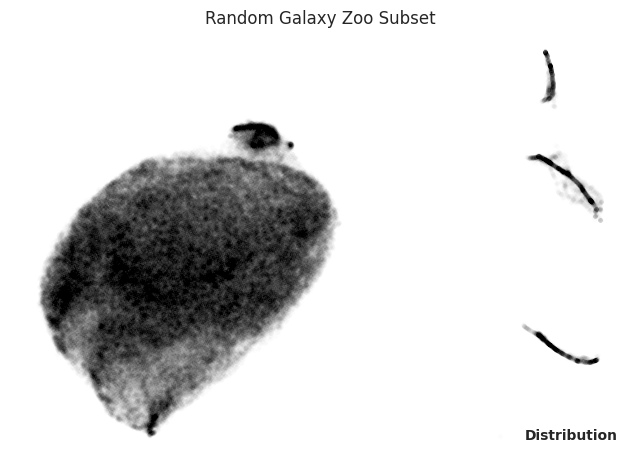

In [15]:
umap_ =viz.umap(rep,name ="Random Galaxy Zoo Subset", min_dist = 0.1, alpha = 0.01) #min_dist = 0.1 for hand sign data


In [ ]:
viz.shade(tmap,labels,numof_class = int(max(labels))+1,alpha = 0.1,name = "UMAP " + data +" " +arch,label = True,gz = True,limits = [-250,150,-200,300], legendd = ["Edge-On","Round Elliptical","Spiral"])#["Boring","Normal","Plumes","S_shaped","Unknown"] )


In [ ]:
viz.shade(tmap,labels,numof_class = int(max(labels))+1,alpha = 0.15,name = "UMAP " + data +" " +arch,label = True,gz = True,limits = [-150,150,-150,150], legendd = ["Edge-On","Round Elliptical","Spiral"])#["Boring","Normal","Plumes","S_shaped","Unknown"] )


In [ ]:
#im = np.random.randint(10000, size=2)
Dir = "/idia/projects/hippo/Koketso/galaxyzoo/galaxy_zoo_12/"
importlib.reload(viz)
im = [7251,4000]
im = np.random.randint(1,700,20)
print(im)
importlib.reload(imf)
for a in im:
    center_image = a
    
    #sim = viz.similarity_search(input_index = center_image,data = pca,number_of_neighbors = 10)
    sim2 = viz.similarity_searchb(input_index = center_image,data = umap_,number_of_neighbors = 8*8)
    #man.show_images([a],meerkat_dir)
    #imf.show_images([a],meerkat_dir)
    #imf.show_images(sim,meerkat_dir)
    viz.shade(umap_,sim2, alpha = 0.2, limits = None)#[-300,300,-300,300])
    plt.show()
    #viz.shade(pmap_2,sim2, alpha = 1)
    #plt.show()
    #viz.show_images(image_2,sim2,5)
    #imf.show_images(sim2,Dir,n_by_n = True,sqrt = 8)
    sim_names = [names[b] for b in sim2]
    imf.show_images(names = sim_names,n_by_n = True,directory = Dir, sqrt = 8)

In [ ]:
import kornia

import kornia.augmentation as K
import random

class RandomRotationWithCrop(K.RandomRotation):
    def __init__(self, degrees, crop_size, output_dim = 244,p = 0.5):
        super(RandomRotationWithCrop, self).__init__(degrees, p = 1)
        #super(RandomRotationWithCrop, self).__init__(crop_size)
        self.rotation_transform = K.RandomRotation(degrees)
        self.crop_transform = K.CenterCrop(crop_size, keepdim = False,align_corners = True)
        self.resize_transform = K.Resize(output_dim)
    def __call__(self, x):
        if random.random() <self.p:
            # Apply random rotation
            x = self.rotation_transform(x)

            # Apply center crop
            x = self.crop_transform(x)
            x = self.resize_transform(x)

        return x

In [ ]:
random.random()

In [ ]:
"""
t_comp =  tv.transforms.Compose([
                        tv.transforms.ToPILImage(),
                        kornia.augmentation.RandomRotation(180),
                        tv.transforms.ToTensor(),
                        tv.transforms.Resize(300),
                        tv.transforms.CenterCrop(224),
                        tv.transforms.Grayscale(num_output_channels = 3),
                        tv.transforms.Normalize(mean=mean, std=std)
         

                            ])
"""

import kornia
#trans_5 = kornia.augmentation.RandomGaussianBlur(kernel_size = [5,5],sigma = [4,4])
trans_5 = kornia.augmentation.RandomRotation([0,360], p=1,keepdim = True, align_corners= True)
#trans_5 = kornia.augmentation.RandomResizedCrop([244,244],scale = (0.6,1), p = 1)
trans_2 = tv.transforms.ToTensor()
trans_3 = tv.transforms.Resize(244)

trans_4 = tv.transforms.CenterCrop(244)
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
trans_6 = tv.transforms.Normalize(mean=mean, std=std)
trans_7 = tv.transforms.Grayscale(num_output_channels = 3)
a= 22012
im1 = trans_2(imf.folder_image_index(galaxyzoo_dir,a)[0])


b_im = trans_7(trans_4(trans_5(trans_3(im1.reshape([1,3,400,400])))))


#b_im = t_comp(trans_3(im1.reshape([1,3,512,512])))
plt.imshow(tv.transforms.ToPILImage()(trans_3(trans_7(trans_6((trans_2(imf.folder_image_index(galaxyzoo_dir,a)[0])))))))
plt.show()
plt.imshow(tv.transforms.ToPILImage()(b_im[0]))
plt.show()

## PCA AND KMEANS

In [54]:
pca = viz.pca(data = rep,n_components = min([1000,len(rep[1])]), variance = 0.95)

Variance to keep :  0.9516112676479733  number of components :  29


In [46]:
from sklearn.cluster import KMeans
n = 15
time_stamp = time.time()
km = KMeans(n_clusters=n,
            init='random',
            n_init=10,
            max_iter=300,
            tol=0.0001,
            verbose=0, 
            random_state=23, 
            copy_x=True,
            algorithm='auto')

k_labels = km.fit_predict(pca)
time2 = time.time()
print(-time_stamp + time.time())

/idia/projects/hippo/Koketso/deepclustering2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1318: FutureWarning: algorithm='auto' is deprecated, it will be removed in 1.3. Using 'lloyd' instead.
  warnings.warn(


1.7838776111602783


In [ ]:
importlib.reload(viz)
viz.shade(umap_,k_labels,numof_class = max(k_labels)+1,label = False,name = " PCA and KMeans",alpha = 0.1, limits =None)# [-5,7,-6,6])

## UMAP and HDBSCAN

In [ ]:
rep = rep_2
name = name_2

In [119]:
np.random.rand(1, 3)

array([[0.9388126 , 0.78884211, 0.38503094]])

In [110]:
import matplotlib.cm as cm
colors = cm.rainbow(np.linspace(0, 1, 20))
colors

In [ ]:
umap_ =viz.umap(rep,name ="Random Galaxy Zoo Subset", min_dist = 0.01, n_neighbors = 20, alpha = 0.01) #min_dist = 0.1 for hand sign data

In [ ]:
rep_file.insert(0,"PCA_KMeans",g_labels)
rep_file

In [71]:
rep_file.to_csv('200sample_res18byol_0_features.csv')

In [ ]:
umap_cluster = viz.umap(rep,scatter = True,name = "UMAP Distribution", dim = 10, min_dist = 0.0, n_neighbors = 30,alpha = 0.2)

In [21]:
pca = viz.pca(data = rep,n_components = min([1000,len(rep[1])]), variance = 0.95)

Variance to keep :  0.9512156374466935  number of components :  31


In [39]:
time_stamp = time.time()
hdbclasses = viz.HDBSCAN(pca,min_cluster_size = 1000, min_samples = 50)
h_labels = hdbclasses
h_labels = [a+1 for a in h_labels]
time2 = time.time()
print(time2-time_stamp)
print(viz.groups(h_labels))

In [51]:
from sklearn.mixture import BayesianGaussianMixture
import time
time_stamp = time.time()

g_labels2 = BayesianGaussianMixture(n_components=20, n_init = 1,weight_concentration_prior=0.5,max_iter = 1000,verbose = 10).fit(pca)

#db_labels = [a+1 for a in db_labels]
time2 = time.time()
print(time2-time_stamp)

Initialization 0
  Iteration 10	 time lapse 50.82578s	 ll change 18679.06548
  Iteration 20	 time lapse 47.43354s	 ll change 5906.58806
  Iteration 30	 time lapse 47.47126s	 ll change 4210.62874
  Iteration 40	 time lapse 48.17871s	 ll change 1482.97137
  Iteration 50	 time lapse 49.66846s	 ll change 2119.95636
  Iteration 60	 time lapse 49.91311s	 ll change 2168.50584
  Iteration 70	 time lapse 50.27719s	 ll change 3708.26896
  Iteration 80	 time lapse 49.34310s	 ll change 777.71548
  Iteration 90	 time lapse 46.81684s	 ll change 590.77334
  Iteration 100	 time lapse 46.38236s	 ll change 284.22012
  Iteration 110	 time lapse 50.54174s	 ll change 141.00123
  Iteration 120	 time lapse 49.56809s	 ll change 66.86231
  Iteration 130	 time lapse 49.18664s	 ll change 30.88340
  Iteration 140	 time lapse 46.71293s	 ll change 25.95769
  Iteration 150	 time lapse 47.51843s	 ll change 23.49463
  Iteration 160	 time lapse 46.50214s	 ll change 18.69450
  Iteration 170	 time lapse 46.41296s	 ll cha

In [52]:
gg_labels2 = g_labels.predict(pca)

In [ ]:
pkl_filename = "BGMM_default_parameters.plk"
    #Load from file
import pickle
print("Saved : ", pkl_filename)
with open(pkl_filename, 'wb') as file:
    pickle.dump(gg_labels,file) 

In [39]:
gg_labels

array([ 0, 17,  9, ..., 11, 14,  7])

In [ ]:
a = np.sort(g_labels.weights_)
b = [round(k,2) for k in a]

In [ ]:
sum([f>0 for f in b])

In [104]:
gg_labels = g_labels.predict(pca)

In [66]:
from sklearn.mixture import GaussianMixture

import time
time_stamp = time.time()

gm_labels = GaussianMixture(n_components=19, random_state=42).fit_predict(pca)

#db_labels = [a+1 for a in db_labels]
time2 = time.time()
print(time2-time_stamp)

179.44714379310608


In [ ]:
importlib.reload(viz)
viz.groups(gg_labels)

In [ ]:
cluster = sum([int(a ==2) for a in gg_labels])

In [ ]:
cluster

In [45]:
plt.style.available?

Type:        list
String form: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic <...> k', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Length:      28
Docstring:  
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.

Plotting


/users/koketso/Feature_extraction/Features/backbone/VISUAL.py:210: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(classes[i][:,0],classes[i][:,1],s = 2,c = col,alpha = alpha)


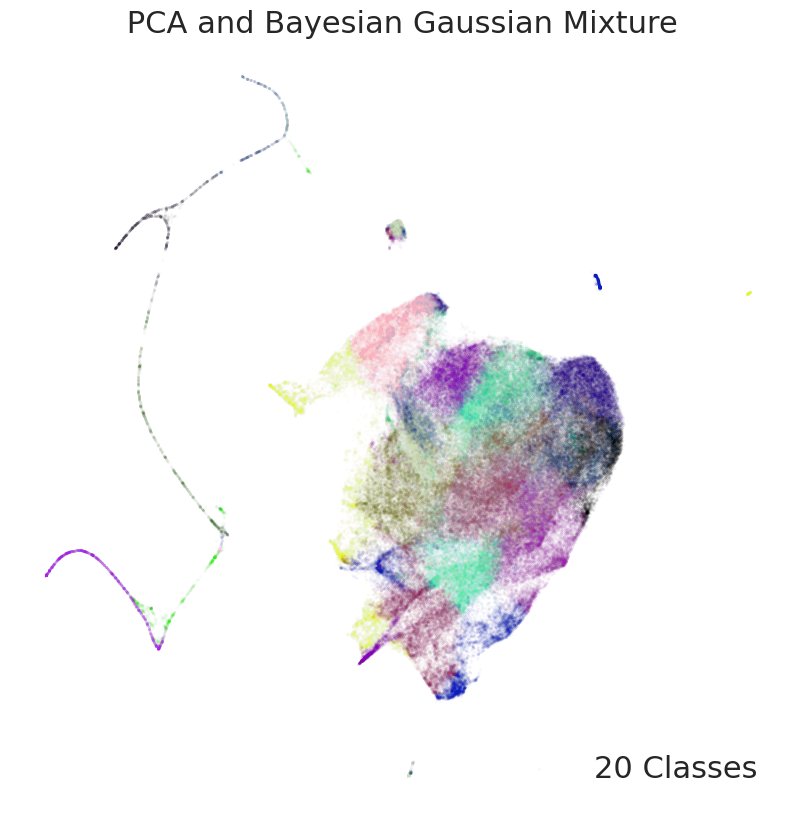

In [53]:

viz.shade(umap_,gg_labels2,numof_class = max(gg_labels2)+1,label = False,name = " PCA and Bayesian Gaussian Mixture",alpha = 0.03, limits =None)# [-5,7,-6,6])

Plotting


/users/koketso/Feature_extraction/Features/backbone/VISUAL.py:210: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(classes[i][:,0],classes[i][:,1],s = 2,c = col,alpha = alpha)


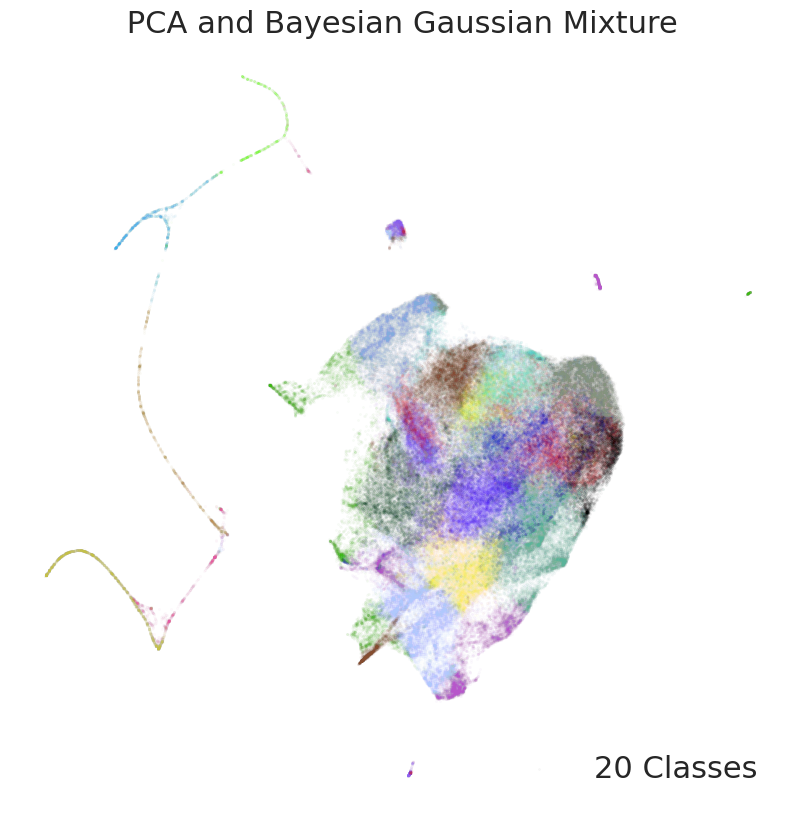

In [49]:
importlib.reload(viz)
viz.shade(umap_,gg_labels,numof_class = max(gg_labels)+1,label = False,name = " PCA and Bayesian Gaussian Mixture",alpha = 0.03, limits =None)# [-5,7,-6,6])